In [1]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 5)
sns.set_theme(style="darkgrid", palette="muted")
print("Libraries loaded ✓")

Libraries loaded ✓


In [3]:
# Cell 2: Load datasets
trades = pd.read_csv(r"C:\Users\SAIM\Downloads\historical_data.csv")
fg     = pd.read_csv(r"C:\Users\SAIM\Downloads\fear_greed_index.csv")

print("Trades shape:", trades.shape)
print("Fear/Greed shape:", fg.shape)
trades.head(3)

Trades shape: (211224, 16)
Fear/Greed shape: (2644, 4)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12


In [4]:
# Cell 3: Clean trades
trades.columns = trades.columns.str.strip().str.lower().str.replace(" ", "_")

# Parse date from 'timestamp_ist' (format: 02-12-2024 22:50)
trades["date"] = pd.to_datetime(trades["timestamp_ist"], dayfirst=True, errors="coerce").dt.date

# Numeric coercion
for col in ["execution_price", "size_tokens", "size_usd", "closed_pnl", "fee"]:
    trades[col] = pd.to_numeric(trades[col], errors="coerce")

trades["closed_pnl"].fillna(0, inplace=True)
trades.dropna(subset=["date"], inplace=True)

print(trades.dtypes)
print(f"\nDate range: {trades['date'].min()} → {trades['date'].max()}")
print(f"Unique traders: {trades['account'].nunique()}")
trades.head(3)

account              object
coin                 object
execution_price     float64
size_tokens         float64
size_usd            float64
side                 object
timestamp_ist        object
start_position      float64
direction            object
closed_pnl          float64
transaction_hash     object
order_id              int64
crossed                bool
fee                 float64
trade_id            float64
timestamp           float64
date                 object
dtype: object

Date range: 2023-05-01 → 2025-05-01
Unique traders: 32


,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02


In [5]:
# Cell 4: Clean Fear/Greed index
fg.columns = fg.columns.str.strip().str.lower()
fg["date"] = pd.to_datetime(fg["date"], errors="coerce").dt.date
fg.dropna(subset=["date"], inplace=True)
fg = fg[["date", "value", "classification"]].drop_duplicates("date")

# Ordered category for plotting
order = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
fg["classification"] = pd.Categorical(fg["classification"], categories=order, ordered=True)

print(fg["classification"].value_counts())
fg.head()

classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64


,date,value,classification
0,2018-02-01,30,Fear
1,2018-02-02,15,Extreme Fear
2,2018-02-03,40,Fear
3,2018-02-04,24,Extreme Fear
4,2018-02-05,11,Extreme Fear


In [6]:
# Cell 5: Merge on date
df = trades.merge(fg, on="date", how="left")

print(f"Rows after merge : {len(df)}")
print(f"Matched rows     : {df['classification'].notna().sum()}")
df[["date","closed_pnl","side","classification","value"]].head()

Rows after merge : 211224
Matched rows     : 211218


,date,closed_pnl,side,classification,value
0,2024-12-02,0.0,BUY,Extreme Greed,80.0
1,2024-12-02,0.0,BUY,Extreme Greed,80.0
2,2024-12-02,0.0,BUY,Extreme Greed,80.0
3,2024-12-02,0.0,BUY,Extreme Greed,80.0
4,2024-12-02,0.0,BUY,Extreme Greed,80.0


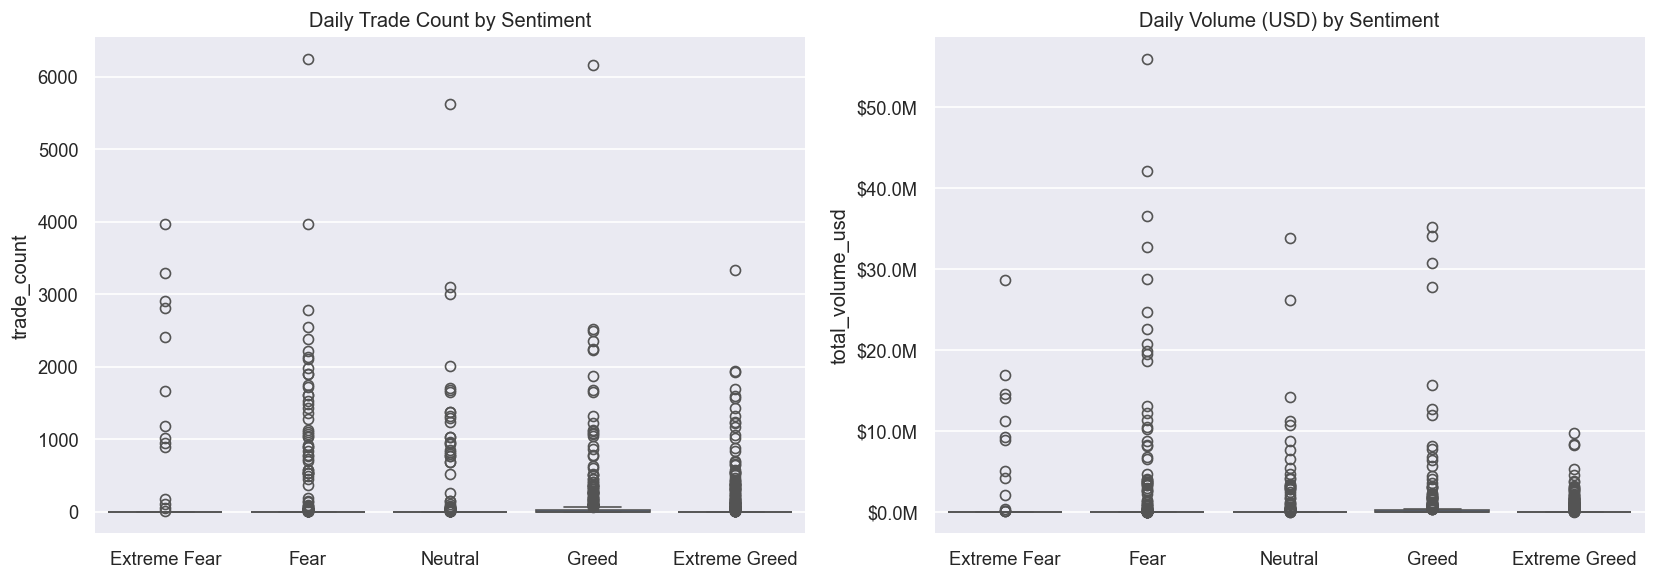

In [7]:
# Cell 6: Daily trade count & volume by sentiment
daily = df.groupby(["date","classification"]).agg(
    trade_count=("closed_pnl","count"),
    total_volume_usd=("size_usd","sum")
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=daily, x="classification", y="trade_count", ax=axes[0])
axes[0].set_title("Daily Trade Count by Sentiment")
axes[0].set_xlabel("")

sns.boxplot(data=daily, x="classification", y="total_volume_usd", ax=axes[1])
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x/1e6:.1f}M"))
axes[1].set_title("Daily Volume (USD) by Sentiment")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

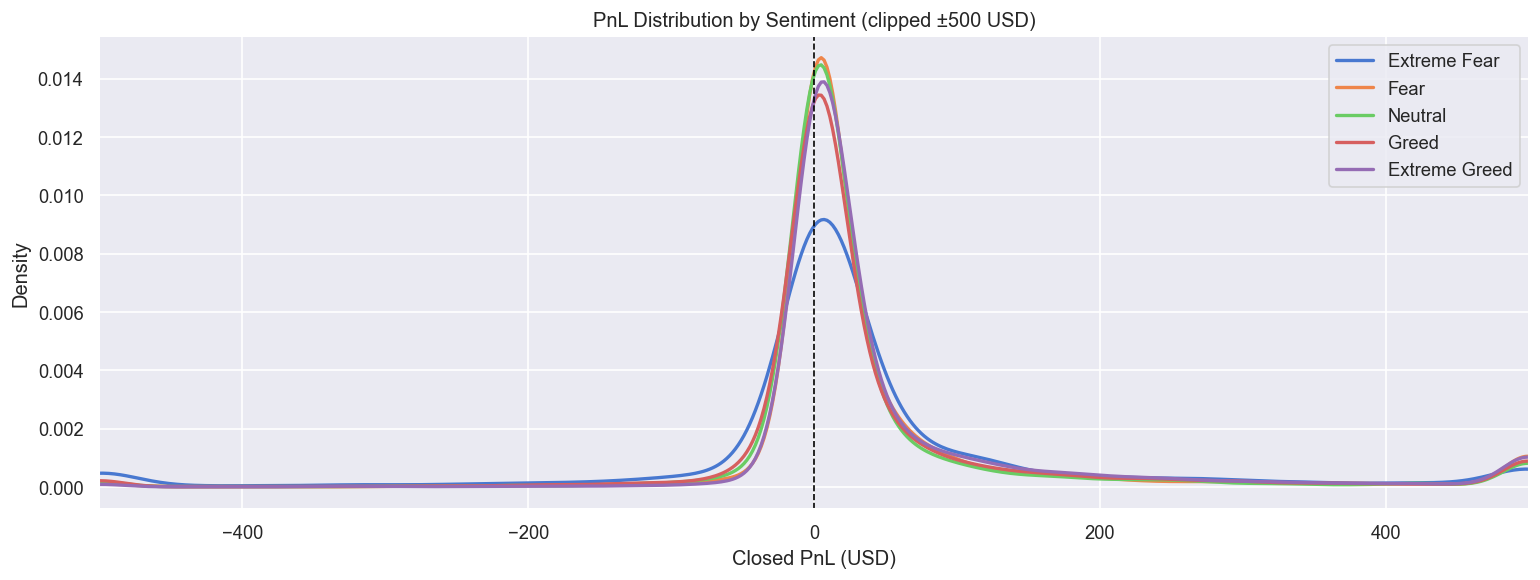

In [8]:
# Cell 7: Closed PnL distribution per sentiment class
# Focus on closing trades (non-zero PnL)
closing = df[df["closed_pnl"] != 0].copy()

fig, ax = plt.subplots(figsize=(13, 5))
for cat in order:
    subset = closing[closing["classification"] == cat]["closed_pnl"]
    if len(subset) > 10:
        subset.clip(-500, 500).plot.kde(ax=ax, label=cat, linewidth=2)

ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_xlim(-500, 500)
ax.set_title("PnL Distribution by Sentiment (clipped ±500 USD)")
ax.set_xlabel("Closed PnL (USD)")
ax.legend()
plt.tight_layout()
plt.show()

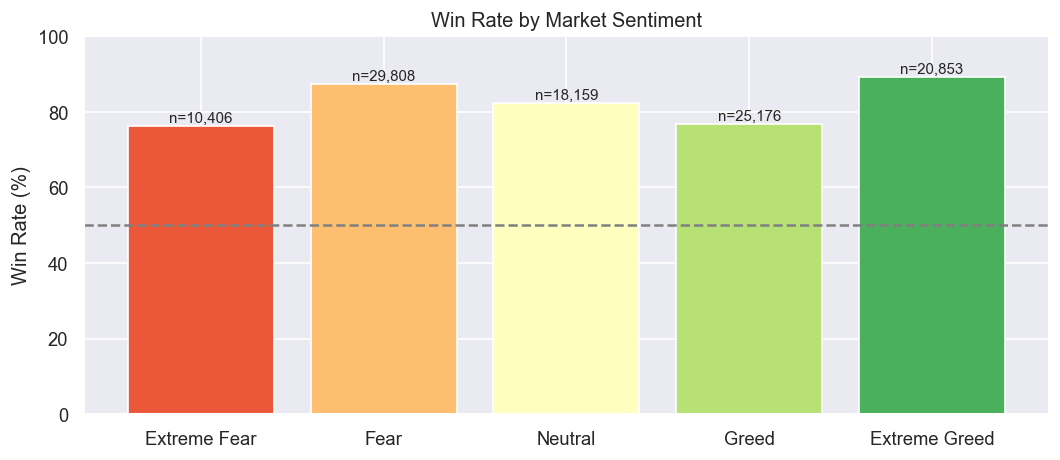

classification  win_rate  n_trades
  Extreme Fear  0.762156     10406
          Fear  0.872886     29808
       Neutral  0.823889     18159
         Greed  0.768907     25176
 Extreme Greed  0.891670     20853


In [9]:
# Cell 8: Win rate (% profitable closing trades) by sentiment
closing["win"] = (closing["closed_pnl"] > 0).astype(int)

win_rate = (closing.groupby("classification")["win"]
            .agg(["mean","count"])
            .rename(columns={"mean":"win_rate","count":"n_trades"})
            .reset_index())

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(win_rate["classification"].astype(str), win_rate["win_rate"]*100,
              color=sns.color_palette("RdYlGn", len(win_rate)))
ax.set_ylim(0, 100)
ax.axhline(50, linestyle="--", color="grey")
ax.set_ylabel("Win Rate (%)")
ax.set_title("Win Rate by Market Sentiment")
for bar, row in zip(bars, win_rate.itertuples()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f"n={row.n_trades:,}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print(win_rate.to_string(index=False))

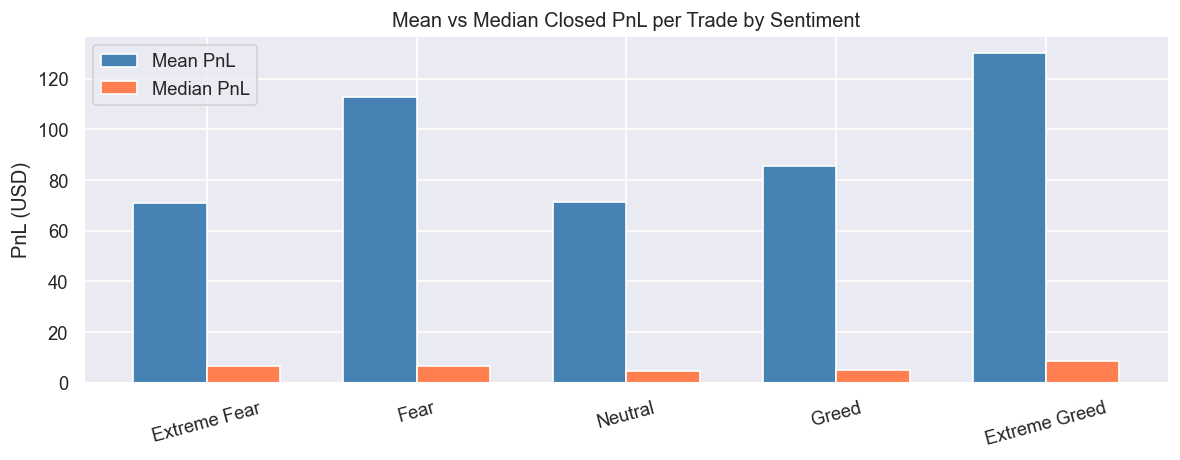

In [10]:
# Cell 9: Mean & median PnL per closing trade by sentiment
pnl_stats = (closing.groupby("classification")["closed_pnl"]
             .agg(mean_pnl="mean", median_pnl="median")
             .reset_index())

x = np.arange(len(pnl_stats))
w = 0.35
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - w/2, pnl_stats["mean_pnl"],   w, label="Mean PnL",   color="steelblue")
ax.bar(x + w/2, pnl_stats["median_pnl"], w, label="Median PnL", color="coral")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(pnl_stats["classification"].astype(str), rotation=15)
ax.set_ylabel("PnL (USD)")
ax.set_title("Mean vs Median Closed PnL per Trade by Sentiment")
ax.legend()
plt.tight_layout()
plt.show()

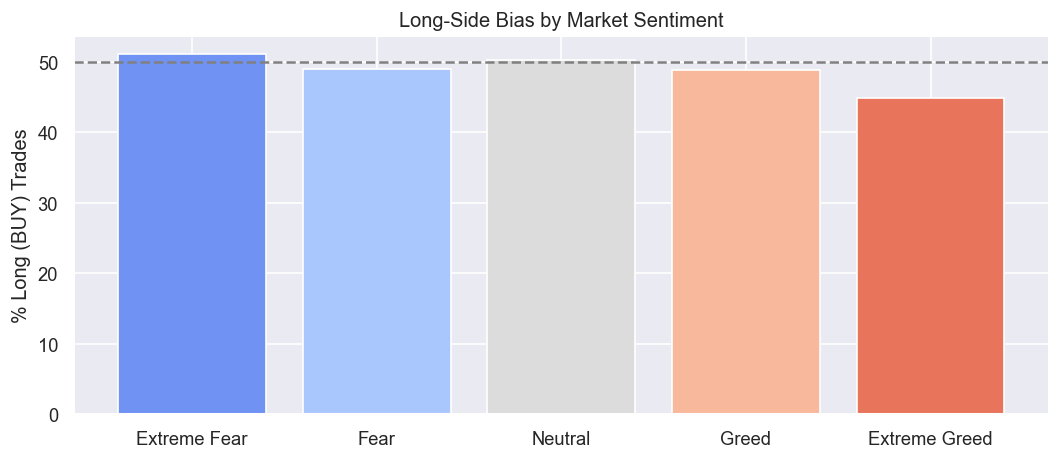

In [11]:
# Cell 10: Buy/Sell ratio by sentiment
side_counts = (df.groupby(["classification","side"])["account"]
               .count().reset_index(name="count"))

pivot = side_counts.pivot_table(index="classification", columns="side", values="count", fill_value=0)
pivot["long_ratio"] = pivot.get("BUY", 0) / (pivot.get("BUY", 0) + pivot.get("SELL", 0))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(pivot.index.astype(str), pivot["long_ratio"]*100,
       color=sns.color_palette("coolwarm", len(pivot)))
ax.axhline(50, linestyle="--", color="grey")
ax.set_ylabel("% Long (BUY) Trades")
ax.set_title("Long-Side Bias by Market Sentiment")
plt.tight_layout()
plt.show()

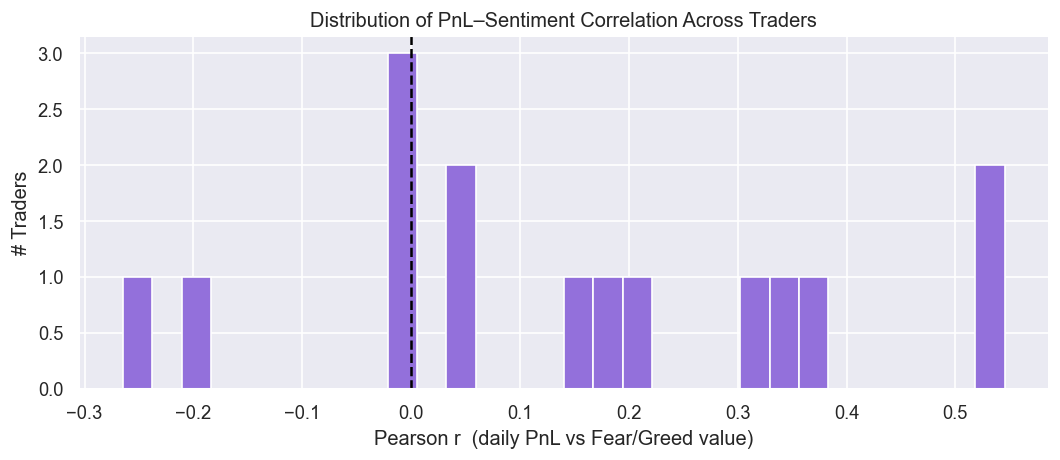

count    15.000000
mean      0.148315
std       0.240589
min      -0.264580
25%      -0.013365
50%       0.155681
75%       0.329962
max       0.545279
Name: pearson_r, dtype: float64


In [12]:
# Cell 11: Per-trader daily PnL vs Fear/Greed value (Pearson r)
trader_daily = (closing.groupby(["account","date"])
                .agg(daily_pnl=("closed_pnl","sum"), fg_value=("value","first"))
                .reset_index())

# Only traders with ≥ 30 active days for reliability
qualified = trader_daily.groupby("account").filter(lambda x: len(x) >= 30)

correlations = (qualified.groupby("account")
                .apply(lambda g: g[["daily_pnl","fg_value"]].corr().iloc[0,1])
                .reset_index(name="pearson_r"))

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(correlations["pearson_r"].dropna(), bins=30, color="mediumpurple", edgecolor="white")
ax.axvline(0, color="black", linestyle="--")
ax.set_xlabel("Pearson r  (daily PnL vs Fear/Greed value)")
ax.set_ylabel("# Traders")
ax.set_title("Distribution of PnL–Sentiment Correlation Across Traders")
plt.tight_layout()
plt.show()

print(correlations["pearson_r"].describe())

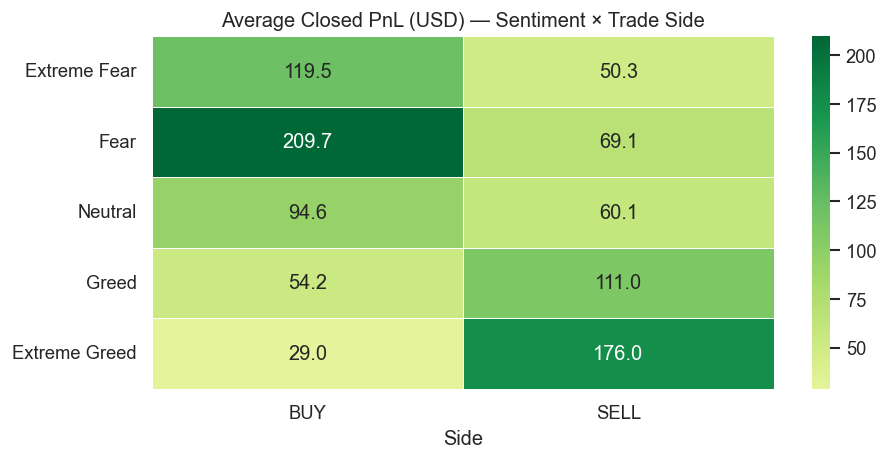

In [13]:
# Cell 12: Pivot heatmap
heatmap_data = (closing.groupby(["classification","side"])["closed_pnl"]
                .mean().unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="RdYlGn",
            linewidths=0.5, ax=ax, center=0)
ax.set_title("Average Closed PnL (USD) — Sentiment × Trade Side")
ax.set_xlabel("Side")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

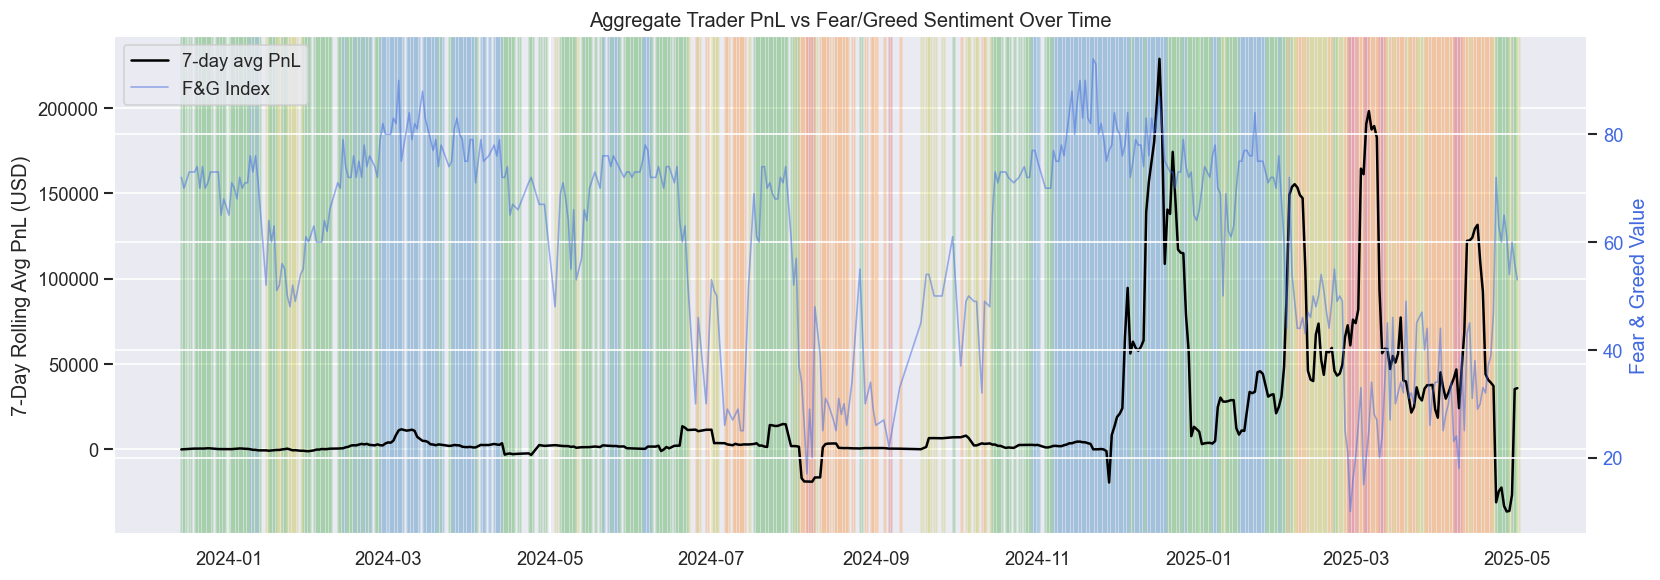

In [14]:
# Cell 13: Time-series overlay
daily_pnl = (closing.groupby("date")["closed_pnl"].sum()
             .reset_index().rename(columns={"closed_pnl":"total_pnl"}))
daily_fg  = fg[["date","value","classification"]].copy()

ts = daily_pnl.merge(daily_fg, on="date", how="inner")
ts["date"] = pd.to_datetime(ts["date"])
ts = ts.sort_values("date")
ts["pnl_7d"] = ts["total_pnl"].rolling(7, min_periods=1).mean()

fig, ax1 = plt.subplots(figsize=(14, 5))
color_map = {"Extreme Fear":"#d62728","Fear":"#ff7f0e",
             "Neutral":"#bcbd22","Greed":"#2ca02c","Extreme Greed":"#1f77b4"}
for _, row in ts.iterrows():
    ax1.axvspan(row["date"], row["date"] + pd.Timedelta(days=1),
                alpha=0.15, color=color_map.get(str(row["classification"]), "grey"))

ax1.plot(ts["date"], ts["pnl_7d"], color="black", linewidth=1.5, label="7-day avg PnL")
ax1.set_ylabel("7-Day Rolling Avg PnL (USD)")
ax1.set_title("Aggregate Trader PnL vs Fear/Greed Sentiment Over Time")

ax2 = ax1.twinx()
ax2.plot(ts["date"], ts["value"], color="royalblue", alpha=0.5, linewidth=1, label="F&G Index")
ax2.set_ylabel("Fear & Greed Value", color="royalblue")
ax2.tick_params(axis="y", labelcolor="royalblue")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc="upper left")
plt.tight_layout()
plt.show()

In [15]:
# Cell 14: One-way ANOVA — does sentiment significantly affect per-trade PnL?
groups = [closing[closing["classification"]==cat]["closed_pnl"].dropna()
          for cat in order if cat in closing["classification"].values]

f_stat, p_val = stats.f_oneway(*groups)
print(f"One-way ANOVA:  F = {f_stat:.3f},  p = {p_val:.4e}")
if p_val < 0.05:
    print("✅ Statistically significant difference in PnL across sentiment classes (p < 0.05)")
else:
    print("❌ No statistically significant difference found (p ≥ 0.05)")

One-way ANOVA:  F = 7.738,  p = 3.1360e-06
✅ Statistically significant difference in PnL across sentiment classes (p < 0.05)


In [16]:
# Cell 15: Final summary table
summary = (closing.groupby("classification").agg(
    n_trades      = ("closed_pnl","count"),
    win_rate_pct  = ("win",        lambda x: round(x.mean()*100,1)),
    mean_pnl      = ("closed_pnl", lambda x: round(x.mean(),2)),
    median_pnl    = ("closed_pnl", lambda x: round(x.median(),2)),
    total_pnl     = ("closed_pnl", lambda x: round(x.sum(),0)),
).reset_index())

print("=" * 65)
print("SUMMARY: Trader Performance by Market Sentiment")
print("=" * 65)
print(summary.to_string(index=False))
print("=" * 65)

SUMMARY: Trader Performance by Market Sentiment
classification  n_trades  win_rate_pct  mean_pnl  median_pnl  total_pnl
  Extreme Fear     10406          76.2     71.03        6.39   739110.0
          Fear     29808          87.3    112.63        6.35  3357155.0
       Neutral     18159          82.4     71.20        4.58  1292921.0
         Greed     25176          76.9     85.40        4.93  2150129.0
 Extreme Greed     20853          89.2    130.21        8.53  2715171.0
